# How much constraining power does a smaller WFD footprint cost?

The LSST wide-fast-deep footprint is not fixed: proposals to trade area for depth, or to
carve out regions, move it around the nominal ~18,000 deg$^2$.  This notebook asks the
narrow, quantitative version of that question with `FisherFlex`:

> For an LSST **Y1** analysis, how do $\sigma(S_8)$ and the $w_0$-$w_a$ figure of merit
> respond as the WFD area is walked down from 18,000 deg$^2$ to 14,000 deg$^2$?

Both **cosmic shear** and **3x2pt** are forecast, over a fine area grid that covers the
14,800-17,500 deg$^2$ range of current footprint proposals.

### What is held fixed

Everything except the area.  The source sample is the DESC nz-challenge task-set 1
**Cardinal 1yr WFD** sample used in [`../nzdc_example/forecast_example.ipynb`](../nzdc_example/forecast_example.ipynb):

| ingredient | value | source |
|---|---|---|
| source $n(z)$ | Cardinal 1yr **truth**, 5 tomographic bins | `..._1yr_nz_true_wfd.hdf5` |
| $n_{\rm eff}$ | 1.72-1.95 arcmin$^{-2}$ per bin (9.07 total) | bin assignments in `..._1yr_bhat_wfd.hdf5` |
| $\sigma_e$ | 0.26 per component | `forecast_example.ipynb` |
| photo-z model | shift + stretch per bin, prior from the 10 $n(z)$ realizations | `..._nz_samples_1yr_wfd.hdf5` |
| scale cuts | $300 < \ell < 1800$ for shear | `forecast_example.ipynb` |

$n_{\rm eff}$ is a **density**, so it does not change with area -- shrinking the footprint
removes galaxies but not galaxies per arcmin$^2$.  Only $f_{\rm sky}$ moves.

Two deliberate choices differ from `forecast_example.ipynb`, both noted again where they
are made: the lens sample is the LSST **Y1** preset (`y1=True`, 5 lens bins) rather than
the Y10 default, and $f_{\rm sky}$ is set from the area under study rather than pinned at
0.5.  The last section checks that neither the truth-vs-estimated $n(z)$ choice nor these
settings change the *fractional* area scaling, which is what the notebook is about.

In [1]:
import numpy as np
import pandas as pd
import qp
import tables_io
from matplotlib import pyplot as plt

from fisherA2Z.fisher_flex import FisherFlex

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

FULL_SKY_DEG2 = 4 * np.pi * (180.0 / np.pi) ** 2   # 41252.96 deg^2

NZDC = "../nzdc_example"            # the nz-challenge inputs live next door
AREA_REF = 18000.0                  # deg^2, the nominal WFD footprint
AREAS = np.arange(14000.0, 18000.1, 100.0)
AREA_LO, AREA_HI = 14800.0, 17500.0  # the footprint range under consideration

SIGMA_E = 0.26
ELL_CUTS = dict(ell_min_cs=300, ell_max_cs=1800)

print(f"full sky = {FULL_SKY_DEG2:.2f} deg^2")
print(f"scanning {AREAS[0]:.0f} -> {AREAS[-1]:.0f} deg^2 "
      f"(f_sky {AREAS[0]/FULL_SKY_DEG2:.4f} -> {AREAS[-1]/FULL_SKY_DEG2:.4f})")

full sky = 41252.96 deg^2
scanning 14000 -> 18000 deg^2 (f_sky 0.3394 -> 0.4363)


## 1. The Cardinal Y1 source sample

The $n(z)$, its realizations and the tomographic bin assignments come straight out of the
nz-challenge files, exactly as in `../nzdc_example/forecast_example.ipynb`.

In [2]:
z_grid = np.linspace(0.01, 3.0, 150)

# 10 realizations x 5 bins, and their mean -- the estimated n(z) and its scatter
qp_nz = qp.read(f"{NZDC}/nz_challenge_taskset_1_cardinal_nz_samples_1yr_wfd.hdf5")
nz_realization = np.swapaxes(qp_nz.pdf(z_grid).reshape(5, 10, 150), 0, 1)
nz_central = np.mean(qp_nz.pdf(z_grid).reshape(5, 10, 150), axis=1)

# the Cardinal 1yr truth: what the five bins really are
nz_true = qp.read(f"{NZDC}/nz_challenge_taskset_1_cardinal_1yr_nz_true_wfd.hdf5").pdf(z_grid)

print("n(z) shapes:", nz_true.shape, "| realizations:", nz_realization.shape)

n(z) shapes: (5, 150) | realizations: (10, 5, 150)


In [3]:
# effective number density per tomographic bin, arcmin^-2 (from forecast_example.ipynb)
N_CARDINAL_1YR = 3505864          # objects in the Cardinal 1yr WFD catalog
N_SAMPLED_OBJ = 1000000           # objects sampled into the challenge files
SIM_SKY_AREA_MIN2 = 107.4295 * 3600   # sim footprint, arcmin^2 (32 nside=32 pixels)

bhat_table = tables_io.read(f"{NZDC}/nz_challenge_taskset_1_cardinal_1yr_bhat_wfd.hdf5")
counts = np.bincount(bhat_table["bhat_for_wide_data"], minlength=5)[:5]
neff = counts * (N_CARDINAL_1YR / SIM_SKY_AREA_MIN2) / N_SAMPLED_OBJ

mean_z = np.trapz(nz_true * z_grid, z_grid, axis=1) / np.trapz(nz_true, z_grid, axis=1)

print(pd.DataFrame({
    "counts": counts,
    "n_eff [arcmin^-2]": np.round(neff, 4),
    "<z> (truth)": np.round(mean_z, 4),
}, index=pd.Index(range(1, 6), name="bin")).to_string())
print(f"\ntotal n_eff = {neff.sum():.3f} arcmin^-2,  sigma_e = {SIGMA_E}")

     counts  n_eff [arcmin^-2]  <z> (truth)
bin                                        
1    196661             1.7827       0.2145
2    196375             1.7801       0.3934
3    189284             1.7159       0.5372
4    214686             1.9461       0.6875
5    202994             1.8401       0.9132

total n_eff = 9.065 arcmin^-2,  sigma_e = 0.26


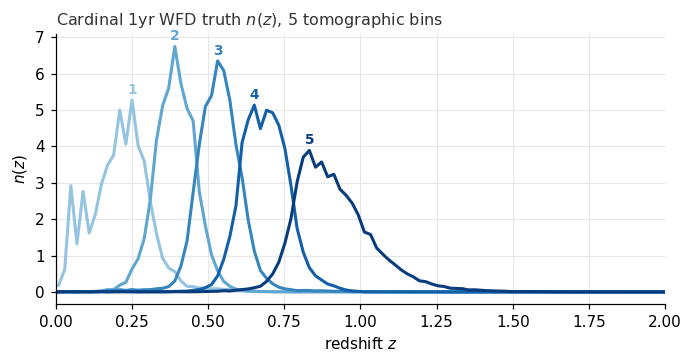

In [4]:
# bins are ordered in redshift, so colour them with one sequential ramp
BIN_COLORS = plt.cm.Blues(np.linspace(0.40, 0.95, 5))

fig, ax = plt.subplots(figsize=(6.4, 3.4))
for i in range(5):
    ax.plot(z_grid, nz_true[i], color=BIN_COLORS[i], lw=2)
    zpk = z_grid[np.argmax(nz_true[i])]
    ax.annotate(f"{i + 1}", (zpk, nz_true[i].max()), xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=9,
                color=BIN_COLORS[i], fontweight="bold")
ax.set_xlim(0, 2.0)
ax.set_xlabel("redshift $z$")
ax.set_ylabel("$n(z)$")
ax.set_title("Cardinal 1yr WFD truth $n(z)$, 5 tomographic bins",
             fontsize=10.5, loc="left", color="0.2")
ax.grid(True, color="0.9", lw=0.7)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

## 2. Area enters the forecast through one number

`FisherFlex` builds a Gaussian covariance

$$\mathrm{Cov}\big(C_\ell^{AB}, C_\ell^{CD}\big) =
\frac{\tilde C_\ell^{AC}\tilde C_\ell^{BD} + \tilde C_\ell^{AD}\tilde C_\ell^{BC}}
     {(2\ell+1)\,\Delta\ell\,f_{\rm sky}},
\qquad \tilde C = C + N,$$

where the noise $N = \sigma_e^2/n_{\rm eff}$ has no $f_{\rm sky}$ in it.  So at fixed
$n_{\rm eff}$ the covariance is **exactly** $\propto 1/f_{\rm sky}$ and the derivatives
$\partial C_\ell/\partial\theta$ do not depend on area at all.  The data part of the Fisher
matrix is therefore strictly linear in area:

$$F(A) = \frac{A}{A_{\rm ref}}\,F_{\rm data}(A_{\rm ref}) + F_{\rm prior}.$$

That is what makes the scan cheap -- one `compute()` per probe, then pure linear algebra
per area point.  It is also *why* the constraints do not follow a naive $A^{-1/2}$ law:
$F_{\rm prior}$ (the cosmology, IA, galaxy-bias and photo-z priors) does not scale with
area, so the more prior-dominated a parameter is, the flatter its area response.

We set up the two probes once, at the reference area.

In [5]:
# The shift/stretch prior is the *scatter* of the n(z) estimator, so it is derived from
# the realizations around their own mean and then attached to the truth-based forecast.
# (Passing nz_realizations directly alongside the truth n(z) would additionally warn about
#  the estimator's offset from the truth -- a statement about bias, which is the subject of
#  ../nzdc_example/bias_example.ipynb, not of this notebook.)
_prior_source = FisherFlex(
    nz_source=nz_central, nz_realizations=nz_realization, z_grid=z_grid,
    neff_source=neff, fsky=AREA_REF / FULL_SKY_DEG2, sigma_e=SIGMA_E,
    mode="cosmic_shear", nz_model="shift_stretch", y1=True, verbose=False,
)
PZ_PRIOR_COV = _prior_source.pz_prior_cov

print("photo-z prior sigmas (per bin):")
print(pd.DataFrame(np.sqrt(np.diagonal(PZ_PRIOR_COV, axis1=1, axis2=2)),
                   columns=["sigma(zbias)", "sigma(zstretch)"],
                   index=pd.Index(range(1, 6), name="bin")).round(5).to_string())

photo-z prior sigmas (per bin):
     sigma(zbias)  sigma(zstretch)
bin                               
1         0.00019          0.00490
2         0.00013          0.00204
3         0.00012          0.00202
4         0.00012          0.00103
5         0.00028          0.00221


In [6]:
def build(mode, nz_source=nz_true, area=AREA_REF):
    """A Cardinal-Y1 FisherFlex for one probe at one footprint area."""
    return FisherFlex(
        # -- the n(z) and its uncertainty ---------------------------------
        nz_source=nz_source,
        photoz_prior_cov=PZ_PRIOR_COV,
        z_grid=z_grid,
        # -- the survey ---------------------------------------------------
        neff_source=neff,                 # arcmin^-2 per bin, independent of area
        fsky=area / FULL_SKY_DEG2,        # the only thing the area changes
        sigma_e=SIGMA_E,
        # -- the analysis -------------------------------------------------
        mode=mode,                        # 'cosmic_shear' or '3x2pt'
        nz_model="shift_stretch",
        y1=True,                          # LSST Y1 lens preset (5 bins), not the Y10 default
        verbose=False,
    )


PROBES = ("cosmic_shear", "3x2pt")
flex = {}
for mode in PROBES:
    flex[mode] = build(mode).compute(parallel=True)
    res = flex[mode].forecast(**ELL_CUTS)
    s8, s8_err = res.s8()
    print(f"{mode:>13} @ {AREA_REF:.0f} deg^2:  S_8 = {s8:.4f} +/- {s8_err:.4f}   "
          f"FoM(w0,wa) = {res.fom('w_0', 'w_a'):6.2f}")

 cosmic_shear @ 18000 deg^2:  S_8 = 0.8523 +/- 0.0145   FoM(w0,wa) =   4.55


        3x2pt @ 18000 deg^2:  S_8 = 0.8523 +/- 0.0043   FoM(w0,wa) =  27.29


### Forecasting at any other area

Rescaling the cached covariance is not an approximation -- it is the same arithmetic
`compute()` would do.  The cell below checks that against a full recomputation at
14,000 deg$^2$.

In [7]:
def forecast_at_area(flex_obj, area, **cuts):
    """Forecast at `area` deg^2 by rescaling the cached covariance (cov ~ 1/f_sky)."""
    saved = flex_obj.cov_blocks
    try:
        flex_obj.cov_blocks = saved * (flex_obj.fsky / (area / FULL_SKY_DEG2))
        return flex_obj.forecast(**{**ELL_CUTS, **cuts})
    finally:
        flex_obj.cov_blocks = saved


check = build("3x2pt", area=14000.0).compute(parallel=True)
direct = check.forecast(**ELL_CUTS)
scaled = forecast_at_area(flex["3x2pt"], 14000.0)

print(f"{'':<12}{'sigma(S_8)':>18}{'FoM(w0,wa)':>18}")
print(f"{'recomputed':<12}{direct.s8()[1]:>18.12e}{direct.fom('w_0', 'w_a'):>18.10f}")
print(f"{'rescaled':<12}{scaled.s8()[1]:>18.12e}{scaled.fom('w_0', 'w_a'):>18.10f}")
print(f"\nmax relative difference: "
      f"{max(abs(direct.s8()[1] / scaled.s8()[1] - 1), abs(direct.fom('w_0', 'w_a') / scaled.fom('w_0', 'w_a') - 1)):.2e}")

                    sigma(S_8)        FoM(w0,wa)
recomputed  4.837144210458e-03     22.3745803048
rescaled    4.837144210457e-03     22.3745803048

max relative difference: 3.92e-13


## 3. The area scan

In [8]:
def scan(flex_by_mode, areas=AREAS):
    """sigma(S_8) and FoM(w0,wa) for each probe over a grid of footprint areas."""
    out = {}
    for mode, f in flex_by_mode.items():
        results = [forecast_at_area(f, a) for a in areas]
        out[mode] = {
            "s8_err": np.array([r.s8()[1] for r in results]),
            "fom": np.array([r.fom("w_0", "w_a") for r in results]),
        }
    return out


scan_true = scan(flex)

table = pd.DataFrame({
    "area [deg^2]": AREAS,
    "f_sky": AREAS / FULL_SKY_DEG2,
    "CS sigma(S8)": scan_true["cosmic_shear"]["s8_err"],
    "CS FoM": scan_true["cosmic_shear"]["fom"],
    "3x2pt sigma(S8)": scan_true["3x2pt"]["s8_err"],
    "3x2pt FoM": scan_true["3x2pt"]["fom"],
}).set_index("area [deg^2]")

in_range = table.loc[AREA_LO:AREA_HI]
print(f"the {AREA_LO:.0f}-{AREA_HI:.0f} deg^2 range, every 300 deg^2:\n")
print(in_range.iloc[::3].to_string(float_format=lambda v: f"{v:10.5f}"))

the 14800-17500 deg^2 range, every 300 deg^2:

                  f_sky  CS sigma(S8)     CS FoM  3x2pt sigma(S8)  3x2pt FoM
area [deg^2]                                                                
14800.0         0.35876       0.01582    4.06423          0.00471   23.36804
15100.0         0.36603       0.01568    4.11048          0.00467   23.73922
15400.0         0.37331       0.01555    4.15652          0.00462   24.10969
15700.0         0.38058       0.01542    4.20236          0.00458   24.47946
16000.0         0.38785       0.01529    4.24800          0.00454   24.84856
16300.0         0.39512       0.01517    4.29345          0.00450   25.21699
16600.0         0.40240       0.01505    4.33872          0.00446   25.58478
16900.0         0.40967       0.01493    4.38380          0.00442   25.95194
17200.0         0.41694       0.01482    4.42872          0.00438   26.31848
17500.0         0.42421       0.01471    4.47346          0.00435   26.68441


## 4. What a smaller footprint costs

The top row is the headline: every curve is normalized to its own value at 18,000 deg$^2$,
so it reads directly as "fraction of the nominal-footprint constraining power".  The dotted
grey line is the pure sample-variance expectation -- $\sigma \propto A^{-1/2}$ and
FoM $\propto A$ -- which the forecasts must fall *short* of, because the priors and the
shape-noise floor do not shrink with the sky.

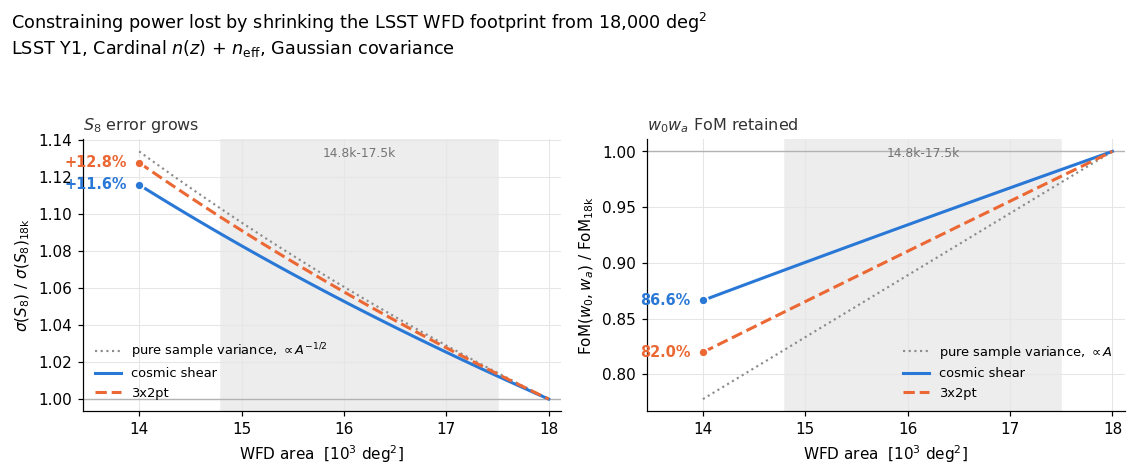

In [9]:
PROBE_STYLE = {
    "cosmic_shear": dict(label="cosmic shear", color="#2a78d6", ls="-"),
    "3x2pt":        dict(label="3x2pt",        color="#eb6834", ls="--"),
}
AREA_K = AREAS / 1e3
I_REF = int(np.argmin(np.abs(AREAS - AREA_REF)))


def dress(ax):
    """Shade the footprint range under consideration; keep grid and spines recessive."""
    ax.axvspan(AREA_LO / 1e3, AREA_HI / 1e3, color="0.93", zorder=0)
    ax.grid(True, color="0.9", lw=0.7)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.set_xlim(AREA_K.min() - 0.55, AREA_K.max() + 0.12)


fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.3))
specs = [
    (axes[0], "s8_err", np.sqrt(AREA_REF / AREAS),
     r"$\sigma(S_8)\ /\ \sigma(S_8)_{18\mathrm{k}}$",
     r"pure sample variance, $\propto A^{-1/2}$", r"$S_8$ error grows",
     "{:+.1%}", lambda v: v - 1, "lower left"),
    (axes[1], "fom", AREAS / AREA_REF,
     r"FoM$(w_0,w_a)\ /\ $FoM$_{18\mathrm{k}}$",
     r"pure sample variance, $\propto A$", r"$w_0w_a$ FoM retained",
     "{:.1%}", lambda v: v, "lower right"),
]
for ax, key, naive, ylab, naive_lab, title, fmt, conv, legend_loc in specs:
    ax.plot(AREA_K, naive, color="0.55", lw=1.4, ls=":", label=naive_lab, zorder=1)
    for mode, st in PROBE_STYLE.items():
        y = scan_true[mode][key]
        y = y / y[I_REF]
        ax.plot(AREA_K, y, color=st["color"], ls=st["ls"], lw=2, label=st["label"], zorder=3)
        ax.plot(AREA_K[0], y[0], "o", ms=6, color=st["color"], mec="white", mew=1.2, zorder=4)
        ax.annotate(fmt.format(conv(y[0])), (AREA_K[0], y[0]), xytext=(-8, 0),
                    textcoords="offset points", va="center", ha="right",
                    fontsize=9.5, color=st["color"], fontweight="bold")
    ax.axhline(1.0, color="0.7", lw=0.9, zorder=2)
    ax.set_ylabel(ylab)
    ax.set_xlabel(r"WFD area  [$10^3$ deg$^2$]")
    ax.set_title(title, fontsize=10.5, loc="left", color="0.2")
    ax.legend(loc=legend_loc, fontsize=8.5, frameon=False)
    dress(ax)
    ax.annotate(f"{AREA_LO/1e3:g}k-{AREA_HI/1e3:g}k",
                ((AREA_LO + AREA_HI) / 2e3, ax.get_ylim()[1]), xytext=(0, -12),
                textcoords="offset points", ha="center", fontsize=8, color="0.45")

fig.suptitle("Constraining power lost by shrinking the LSST WFD footprint from 18,000 deg$^2$\n"
             "LSST Y1, Cardinal $n(z)$ + $n_{\\rm eff}$, Gaussian covariance",
             fontsize=11.5, x=0.012, y=0.995, va="top", ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.945))
fig.savefig("wfd_footprint_relative.png", dpi=130)
plt.show()

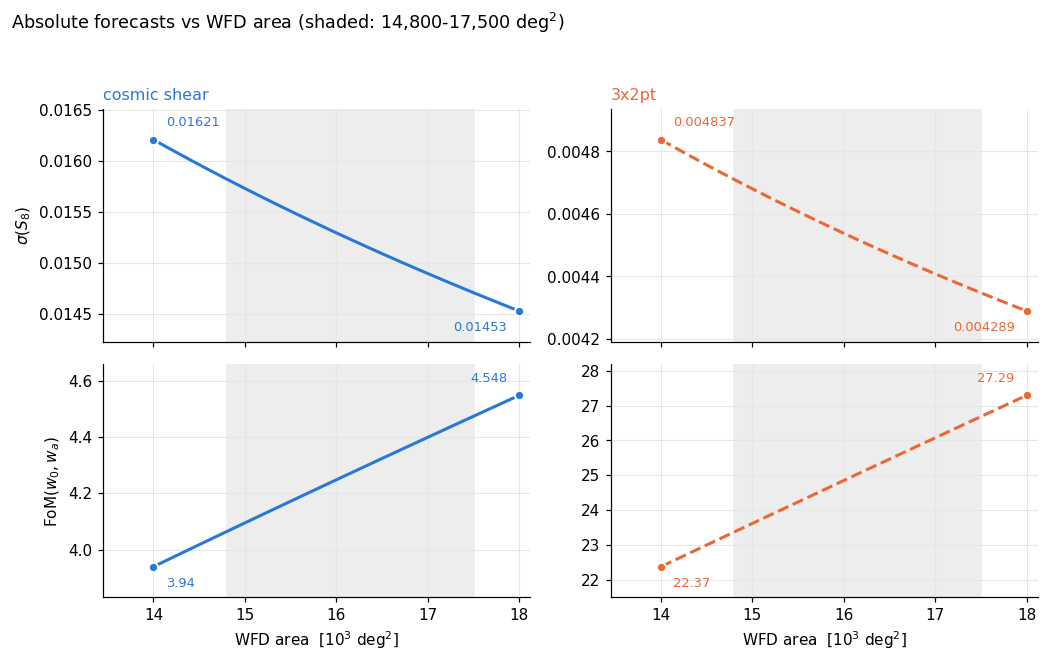

In [10]:
# the same scan in absolute units -- one panel per probe, since the two differ by ~3x
fig, axes = plt.subplots(2, 2, figsize=(9.6, 6.0), sharex=True)
for col, (mode, st) in enumerate(PROBE_STYLE.items()):
    for row, (key, ylab) in enumerate(((  "s8_err", r"$\sigma(S_8)$"),
                                       (  "fom",    r"FoM$(w_0,w_a)$"))):
        ax = axes[row, col]
        y = scan_true[mode][key]
        ax.plot(AREA_K, y, color=st["color"], ls=st["ls"], lw=2)
        ax.plot([AREA_K[0], AREA_K[I_REF]], [y[0], y[I_REF]], "o", ms=6,
                color=st["color"], mec="white", mew=1.2)
        # put each endpoint label in the corner the curve leaves free
        ends = (((0, "left", 8, 9), (I_REF, "right", -8, -13)) if row == 0
                else ((0, "left", 8, -13), (I_REF, "right", -8, 9)))
        for i, ha, dx, dy in ends:
            ax.annotate(f"{y[i]:.4g}", (AREA_K[i], y[i]), xytext=(dx, dy),
                        textcoords="offset points", ha=ha, fontsize=8.5, color=st["color"])
        ax.margins(y=0.18)
        if row == 0:
            ax.set_title(st["label"], fontsize=10.5, color=st["color"], loc="left")
        if col == 0:
            ax.set_ylabel(ylab)
        if row == 1:
            ax.set_xlabel(r"WFD area  [$10^3$ deg$^2$]")
        dress(ax)

fig.suptitle(f"Absolute forecasts vs WFD area "
             f"(shaded: {AREA_LO:,.0f}-{AREA_HI:,.0f} deg$^2$)",
             fontsize=11.5, x=0.012, y=0.995, va="top", ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.965))
fig.savefig("wfd_footprint_absolute.png", dpi=130)
plt.show()

### Reading it off

A power law $X \propto A^{p}$ fitted across the scan summarizes the response in one number
per metric.  Pure sample variance would give $p = -1/2$ for $\sigma(S_8)$ and $p = +1$ for
the FoM; anything shallower is the prior and the shape-noise floor taking over.

In [11]:
rows = []
for mode in PROBES:
    for key, naive_p in (("s8_err", -0.5), ("fom", 1.0)):
        y = scan_true[mode][key]
        p = np.polyfit(np.log(AREAS), np.log(y), 1)[0]
        rows.append({
            "probe": PROBE_STYLE[mode]["label"],
            "metric": "sigma(S_8)" if key == "s8_err" else "FoM(w0,wa)",
            "fitted p": p,
            "sample-variance p": naive_p,
            "18k value": y[I_REF],
            "14.8k / 18k": y[int(np.argmin(np.abs(AREAS - AREA_LO)))] / y[I_REF],
            "14k / 18k": y[0] / y[I_REF],
        })

print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:11.5g}"))

print("\nGoing from 18,000 to 14,000 deg^2 (-22% of the sky):")
for mode in PROBES:
    lab = PROBE_STYLE[mode]["label"]
    d_s8 = scan_true[mode]["s8_err"][0] / scan_true[mode]["s8_err"][I_REF] - 1
    d_fom = scan_true[mode]["fom"][0] / scan_true[mode]["fom"][I_REF] - 1
    print(f"  {lab:>13}:  sigma(S_8) {d_s8:+.1%},  FoM {d_fom:+.1%}")

       probe     metric    fitted p  sample-variance p   18k value  14.8k / 18k   14k / 18k
cosmic shear sigma(S_8)    -0.43608               -0.5    0.014526       1.0892      1.1158
cosmic shear FoM(w0,wa)     0.57113                  1      4.5477       0.8937     0.86633
       3x2pt sigma(S_8)    -0.47849               -0.5   0.0042891       1.0982      1.1278
       3x2pt FoM(w0,wa)     0.79087                  1      27.293      0.85619     0.81979

Going from 18,000 to 14,000 deg^2 (-22% of the sky):
   cosmic shear:  sigma(S_8) +11.6%,  FoM -13.4%
          3x2pt:  sigma(S_8) +12.8%,  FoM -18.0%


## 5. Does the choice of $n(z)$ change the answer?

The absolute numbers above do depend on which $n(z)$ is used -- the truth and the
challenge's estimated (central) $n(z)$ differ by up to 0.009 in $\langle z\rangle$, which
is enough to move the Y1 FoM noticeably.  The *area scaling* should not care, and that is
the claim the notebook rests on.  Repeating the whole scan with the estimated $n(z)$ tests
it directly.

In [12]:
flex_cen = {m: build(m, nz_source=nz_central).compute(parallel=True) for m in PROBES}
scan_cen = scan(flex_cen)

rows = []
for mode in PROBES:
    for key, name in (("s8_err", "sigma(S_8)"), ("fom", "FoM(w0,wa)")):
        t = scan_true[mode][key]
        c = scan_cen[mode][key]
        rows.append({
            "probe": PROBE_STYLE[mode]["label"],
            "metric": name,
            "18k, truth n(z)": t[I_REF],
            "18k, central n(z)": c[I_REF],
            "14k/18k truth": t[0] / t[I_REF],
            "14k/18k central": c[0] / c[I_REF],
            "ratio-of-ratios": (c[0] / c[I_REF]) / (t[0] / t[I_REF]),
        })
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:11.5g}"))

       probe     metric  18k, truth n(z)  18k, central n(z)  14k/18k truth  14k/18k central  ratio-of-ratios
cosmic shear sigma(S_8)         0.014526           0.014685         1.1158           1.1134          0.99786
cosmic shear FoM(w0,wa)           4.5477             3.8705        0.86633          0.89517           1.0333
       3x2pt sigma(S_8)        0.0042891          0.0046453         1.1278           1.1196          0.99277
       3x2pt FoM(w0,wa)           27.293             19.722        0.81979          0.84415           1.0297


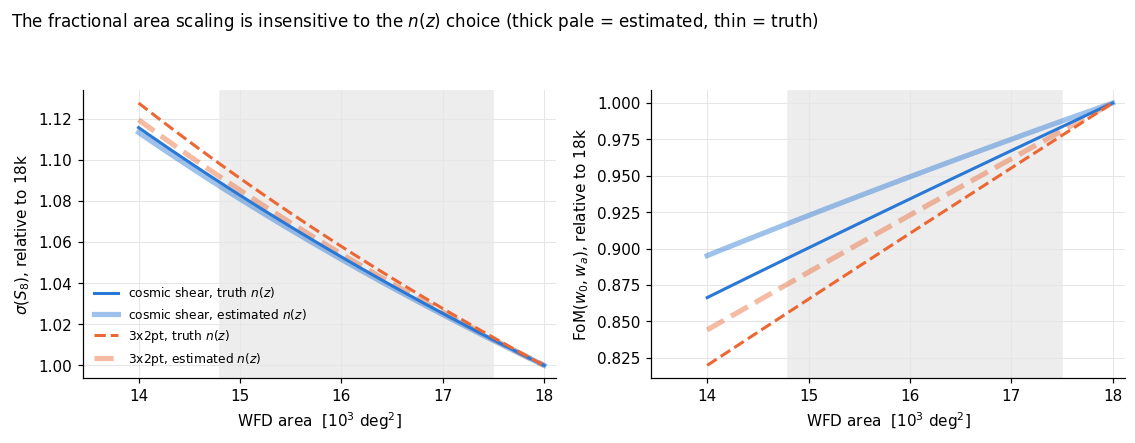

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0), sharex=True)
for ax, key, ylab in ((axes[0], "s8_err", r"$\sigma(S_8)$, relative to 18k"),
                      (axes[1], "fom", r"FoM$(w_0,w_a)$, relative to 18k")):
    for mode, st in PROBE_STYLE.items():
        for scan_res, alpha, lw, tag in ((scan_true, 1.0, 2.0, "truth $n(z)$"),
                                         (scan_cen, 0.45, 3.4, "estimated $n(z)$")):
            y = scan_res[mode][key]
            ax.plot(AREA_K, y / y[I_REF], color=st["color"], ls=st["ls"], lw=lw,
                    alpha=alpha, zorder=3 if alpha == 1.0 else 2,
                    label=f"{st['label']}, {tag}")
    ax.set_ylabel(ylab)
    ax.set_xlabel(r"WFD area  [$10^3$ deg$^2$]")
    dress(ax)
axes[0].legend(fontsize=8, frameon=False, loc="lower left")
fig.suptitle("The fractional area scaling is insensitive to the $n(z)$ choice "
             "(thick pale = estimated, thin = truth)",
             fontsize=11, x=0.012, y=0.995, va="top", ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## Caveats

- **The covariance is Gaussian only.** `FisherFlex` has no non-Gaussian or super-sample
  term, so the absolute FoMs here are optimistic relative to the SRD/A2Z numbers.  SSC in
  particular scales differently with area than sample variance does, so the *slopes* in
  section 4 are upper limits on how steeply the real analysis rewards area.
- **Depth is held fixed.** A real footprint trade buys area with exposure time, which moves
  $n_{\rm eff}$ and the $n(z)$ as well.  This notebook isolates the pure area term; to study
  the trade, vary `neff_source` along with `fsky`.
- **Y1 only.** The Y1 $w_0$-$w_a$ FoM is close to prior-dominated (a prior-only FoM is
  $1/(0.8 \times 1.3) \approx 0.96$, against ~4.5 for cosmic shear here), which is exactly
  why the cosmic-shear FoM curve is so much flatter than $\propto A$.  A Y10 sample sits
  further from the prior and will respond more steeply; rerun with the Y10 preset and a
  Y10 $n_{\rm eff}$ to see that.
- **The photo-z prior is held fixed with area.** In reality a smaller footprint has the
  same calibration sample, so this is the right choice here -- but a footprint change that
  also changed the calibration fields would need `PZ_PRIOR_COV` rebuilt.